[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nepslor/B5203E-TSAF/blob/main/W1/L1_data_visualization.ipynb)

# Time Series visualization and analysis

In this exercise we will go through an example of exploratory analyisis and time series visualization with python. We will usa a dataset containing power measurements and meteorological forecasts relative to a set of **24 power meters** located in Rolle (Switzerland).


<img src="https://raw.githubusercontent.com/nepslor/teaching/main/TimeSeriesForecasting/figs/REeL_Demo_grid.png" width="500"/>

The yellow dots in the image shows the positions of the power meters.
Besides power readings, the dataset includes **temperatue** and **irradiance** measurements from a local meteo station.

Let's start downlowading and looking at the first rows of the dataset:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

from IPython.display import display
import ipywidgets as widgets

try:
    from google.colab import output
    output.enable_custom_widget_manager()
except Exception:
    pass

df_all = pd.read_pickle("https://github.com/nepslor/teaching/raw/refs/heads/main/TimeSeriesForecasting/data/power_dataset.pk")
df_all.head()


,meter_0,meter_1,meter_2,meter_3,meter_4,meter_5,meter_6,meter_7,meter_8,meter_9,...,meter_17,meter_18,meter_19,meter_20,meter_21,meter_22,meter_23,temperature,irradiance,power
2018-01-13 00:00:00+00:00,10.924067,19.971333,10.991000,19.610267,22.568533,39.373467,24.236733,10.682333,30.438467,12.038400,...,15.705800,38.678267,28.880200,46.987067,9.210600,15.278733,18.995333,3.619487,0.0,573.045600
2018-01-13 01:00:00+00:00,10.418056,18.249444,8.453500,19.379667,22.487500,36.460167,24.178667,14.893389,32.995056,11.507889,...,15.430444,30.323444,25.714056,36.692833,8.838111,15.119389,18.283167,3.561266,0.0,532.118167
2018-01-13 02:00:00+00:00,10.428778,17.734056,9.990833,19.463278,22.510944,32.887722,22.883222,18.594500,26.831222,12.133444,...,14.510833,18.565000,23.154056,34.869167,9.051500,14.609167,20.989000,3.473098,0.0,512.772444
2018-01-13 03:00:00+00:00,10.892167,17.687778,9.766611,19.478611,23.554167,34.537278,23.711889,17.007222,25.109667,11.699833,...,15.292111,18.035000,22.533889,39.150500,8.748500,14.864056,18.554611,3.339855,0.0,519.231000
2018-01-13 04:00:00+00:00,11.541611,20.967889,11.316667,20.230556,22.401667,36.215833,23.156778,19.735889,26.673556,12.270556,...,16.577556,21.559167,25.279667,29.315611,9.250111,14.716278,15.858500,2.976714,0.0,531.898889


In [2]:
# last timestep in the dataset
print(df_all.index[-1])

# descriptive statistics for the columns in the dataset
df_all.describe()

2019-01-19 23:00:00+00:00


,meter_0,meter_1,meter_2,meter_3,meter_4,meter_5,meter_6,meter_7,meter_8,meter_9,...,meter_17,meter_18,meter_19,meter_20,meter_21,meter_22,meter_23,temperature,irradiance,power
count,8928.000000,8928.000000,8928.000000,8928.000000,8928.000000,8928.000000,8928.000000,8928.000000,8928.000000,8928.000000,...,8928.000000,8928.000000,8928.000000,8928.000000,8928.000000,8928.000000,8928.000000,8928.000000,8928.000000,8928.000000
mean,13.240240,22.995100,9.776416,23.408987,42.296906,42.363499,43.060888,15.992326,23.213427,22.036370,...,37.519405,19.556278,26.096104,44.395269,9.500617,16.908534,17.898936,12.119505,158.888095,654.888576
std,3.401995,9.108327,4.124793,10.648852,15.279982,9.175827,22.483835,4.735273,10.224178,7.456191,...,16.142299,8.348750,9.709986,10.448556,2.980065,5.543842,4.734135,8.246418,247.515868,139.533158
min,6.706778,9.435389,-1.621667,6.777222,20.426500,22.024222,15.064111,7.079111,3.121500,9.633000,...,13.255056,4.370111,9.304611,12.718889,4.181444,5.528722,0.000000,-10.242634,0.000000,377.562500
25%,10.643542,16.259292,6.406708,14.299653,30.276014,34.698444,24.934319,12.437653,14.009056,16.428056,...,22.019444,12.683736,19.053250,37.040056,7.414806,12.680611,14.674667,5.114249,0.000000,543.453083
50%,12.604417,21.091528,9.571444,22.436472,39.479056,41.050028,31.576111,15.979583,22.216667,20.602500,...,37.715917,18.232194,24.796556,44.977278,9.183556,16.347083,17.509861,11.720683,13.175627,658.609194
75%,15.382194,28.689097,12.649139,30.167847,53.104556,49.343014,61.689625,18.943194,31.060764,26.366181,...,49.183986,24.419806,32.776333,52.105931,11.349361,20.674250,20.725431,18.725921,226.812266,747.264875
max,25.899500,61.308000,23.763167,65.163278,85.615500,70.580667,105.554389,37.123833,58.556389,62.314278,...,99.361889,50.935111,59.322167,75.778444,22.209611,37.425889,38.202500,32.871330,953.900356,1108.712889


We see that:
* the dataset contains 3 signals, the power and two covariates, irradiance and temperature, possibily useful to predict the power
* The datase has hourly timestamps
* It start Jan 2018 and ends Jan 2019
* Each signals contains 8928 values

## Check for missing values and timestamp regularity
We can check if data presents some missing values:

In [3]:
df_all.isna().sum()

meter_0        0
meter_1        0
meter_2        0
meter_3        0
meter_4        0
meter_5        0
meter_6        0
meter_7        0
meter_8        0
meter_9        0
meter_10       0
meter_11       0
meter_12       0
meter_13       0
meter_14       0
meter_15       0
meter_16       0
meter_17       0
meter_18       0
meter_19       0
meter_20       0
meter_21       0
meter_22       0
meter_23       0
temperature    0
irradiance     0
power          0
dtype: int64

And the distribution of sampling times:

In [4]:
df_all.index.diff().value_counts()

0 days 01:00:00    8927
Name: count, dtype: int64

The only present sampling time is 1 hour, this means the series is regularly sampled.

## Line plots
We can try to plot a subset of the dataset as lineplot via pandas:

array([<Axes: >, <Axes: >, <Axes: >], dtype=object)

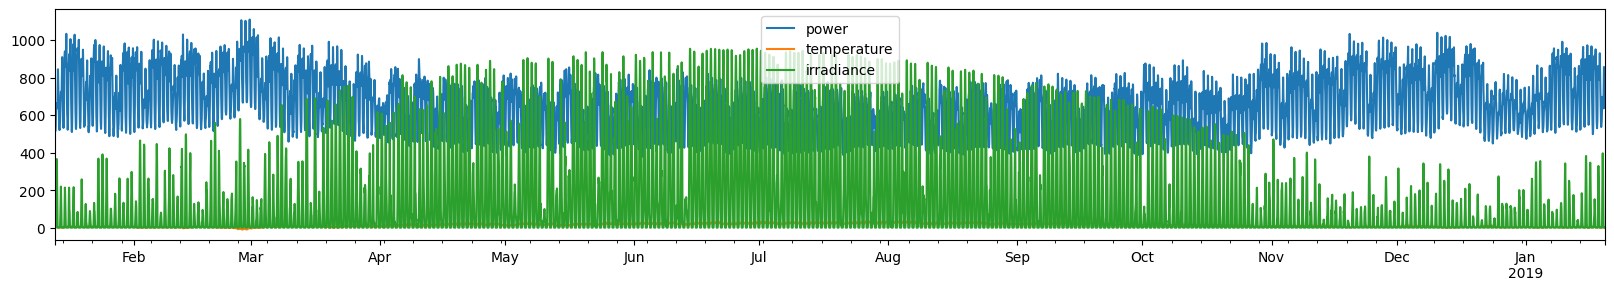

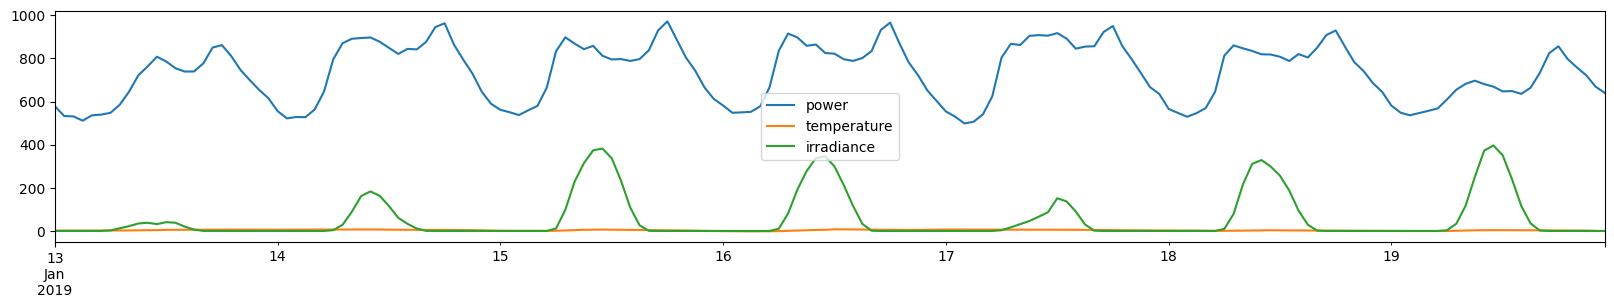

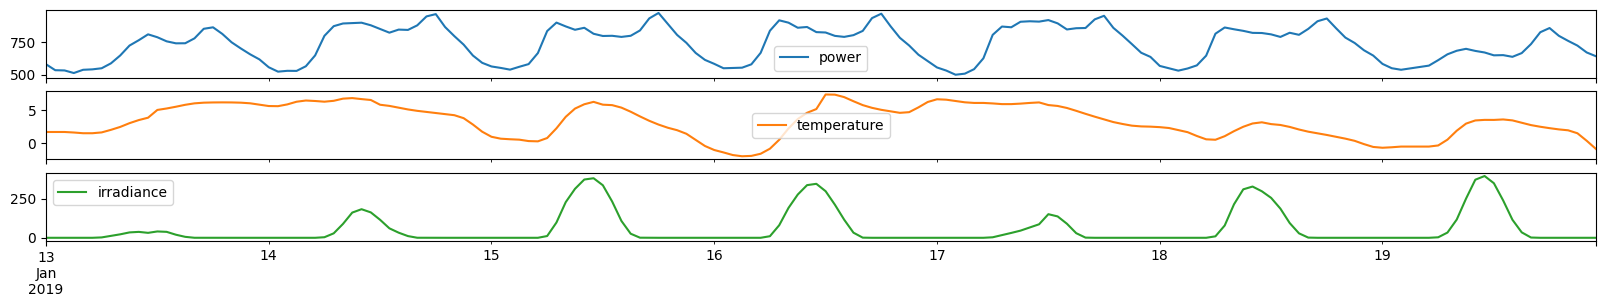

In [5]:
data = df_all[['power', 'temperature', 'irradiance']]

# simple plot
data.plot(figsize=(20, 3))

# last 7 days plot
data.tail(24*7).plot(figsize=(20, 3))

# since signals have different scales, it is useful to plot them in separate axes:
data.tail(24*7).plot(figsize=(20, 3), subplots=True)

## Interactive time-window explorer

Line plots are usually the first visualization for a time series, but they become much more useful when we can choose the signal, zoom level, aggregation, and smoothing.

Mini investigation:

1. Find one week where `power` behaves unusually.
2. Switch from hourly to daily aggregation. Which patterns become easier to see? Which disappear?
3. Turn on the rolling quantile band. Where is the variability largest?


In [6]:
meter_cols = df_all.filter(like='meter').columns.to_list()
main_signals = ['power', 'temperature', 'irradiance']
all_signals = main_signals + meter_cols

first_day = df_all.index.min().normalize()
last_day = df_all.index.max().normalize()
n_days = int((last_day - first_day) / pd.Timedelta(days=1))

def plot_time_window(signal, day_range, aggregation, rolling_points, show_band):
    start = first_day + pd.Timedelta(days=day_range[0])
    end = first_day + pd.Timedelta(days=day_range[1] + 1)
    series = df_all.loc[start:end, signal].dropna()

    if aggregation != 'hourly':
        rule = {'daily mean': 'D', 'weekly mean': 'W'}[aggregation]
        series = series.resample(rule).mean()

    if series.empty:
        print('No data in this time window.')
        return

    rolling_points = max(1, min(rolling_points, len(series)))
    min_periods = max(1, rolling_points // 3)
    rolling_mean = series.rolling(rolling_points, min_periods=min_periods).mean()

    fig, ax = plt.subplots(figsize=(14, 4))
    series.plot(ax=ax, color='0.65', linewidth=0.8, label=signal)

    if show_band and rolling_points > 1:
        q10 = series.rolling(rolling_points, min_periods=min_periods).quantile(0.10)
        q90 = series.rolling(rolling_points, min_periods=min_periods).quantile(0.90)
        ax.fill_between(q10.index, q10.to_numpy(), q90.to_numpy(),
                        color='tab:blue', alpha=0.15, label='rolling 10-90% band')

    rolling_mean.plot(ax=ax, color='tab:blue', linewidth=2,
                      label=f'rolling mean ({rolling_points} points)')
    ax.set_title(f'{signal} from {start.date()} to {(end - pd.Timedelta(days=1)).date()}')
    ax.set_xlabel('time')
    ax.set_ylabel(signal)
    ax.grid(alpha=0.2)
    ax.legend(loc='best')
    plt.show()

time_window_widget = widgets.interactive(
    plot_time_window,
    signal=widgets.Dropdown(options=all_signals, value='power', description='signal'),
    day_range=widgets.IntRangeSlider(value=[0, min(14, n_days)], min=0, max=n_days, step=1,
                                     description='days', continuous_update=False,
                                     layout=widgets.Layout(width='95%')),
    aggregation=widgets.ToggleButtons(options=['hourly', 'daily mean', 'weekly mean'],
                                      value='hourly', description='aggregate'),
    rolling_points=widgets.IntSlider(value=24, min=1, max=24*7, step=1,
                                     description='rolling', continuous_update=False),
    show_band=widgets.Checkbox(value=True, description='quantile band'),
)
display(time_window_widget)


interactive(children=(Dropdown(description='signal', options=('power', 'temperature', 'irradiance', 'meter_0',…

## Calendar distributions: boxplots and violin plots

A line plot answers "what happened when?". Boxplots and violin plots answer a different question: "what values are typical for each hour, weekday, month, or weekend type?"

Mini investigation:

1. Which grouping best reveals the daily cycle?
2. Which grouping best reveals the difference between weekdays and weekends?
3. Try both boxplots and violin plots. Which is easier to read for this dataset?


In [ ]:
weekday_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

calendar_features = pd.DataFrame(index=df_all.index)
calendar_features['hour'] = df_all.index.hour
calendar_features['weekday'] = pd.Categorical(
    df_all.index.day_name().str[:3], categories=weekday_order, ordered=True)
calendar_features['month'] = pd.Categorical(
    df_all.index.month_name().str[:3], categories=month_order, ordered=True)
calendar_features['weekend'] = np.where(df_all.index.dayofweek >= 5, 'weekend', 'weekday')

def seasonal_distribution(signal, group_by, plot_type):
    frame = df_all[[signal]].join(calendar_features).dropna()
    order = None
    if group_by == 'hour':
        order = list(range(24))
    elif group_by == 'weekday':
        order = weekday_order
    elif group_by == 'month':
        order = month_order
    elif group_by == 'weekend':
        order = ['weekday', 'weekend']

    fig, ax = plt.subplots(figsize=(14, 4))
    if plot_type == 'boxplot':
        sb.boxplot(data=frame, x=group_by, y=signal, order=order,
                   showfliers=False, color='lightsteelblue', ax=ax)
    else:
        sb.violinplot(data=frame, x=group_by, y=signal, order=order,
                      inner='quartile', cut=0, color='lightsteelblue', ax=ax)

    ax.set_title(f'{signal}: distribution by {group_by}')
    ax.grid(axis='y', alpha=0.2)
    plt.show()

seasonal_widget = widgets.interactive(
    seasonal_distribution,
    signal=widgets.Dropdown(options=main_signals, value='power', description='signal'),
    group_by=widgets.ToggleButtons(options=['hour', 'weekday', 'month', 'weekend'],
                                   value='hour', description='group'),
    plot_type=widgets.ToggleButtons(options=['boxplot', 'violin'], value='boxplot', description='plot'),
)
display(seasonal_widget)


interactive(children=(Dropdown(description='signal', options=('power', 'temperature', 'irradiance'), value='po…

Let's plot the power meters' readings, filtering the dataset using the `.filter` method and the `like` argument

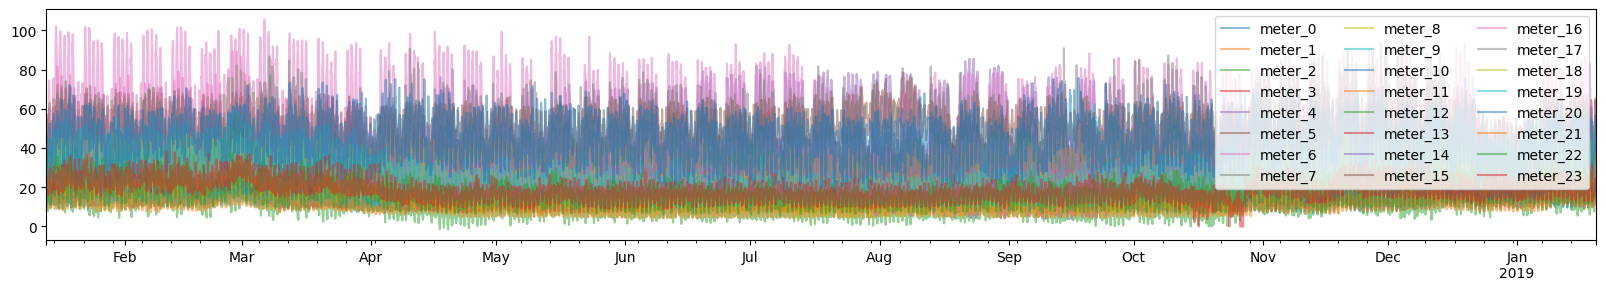

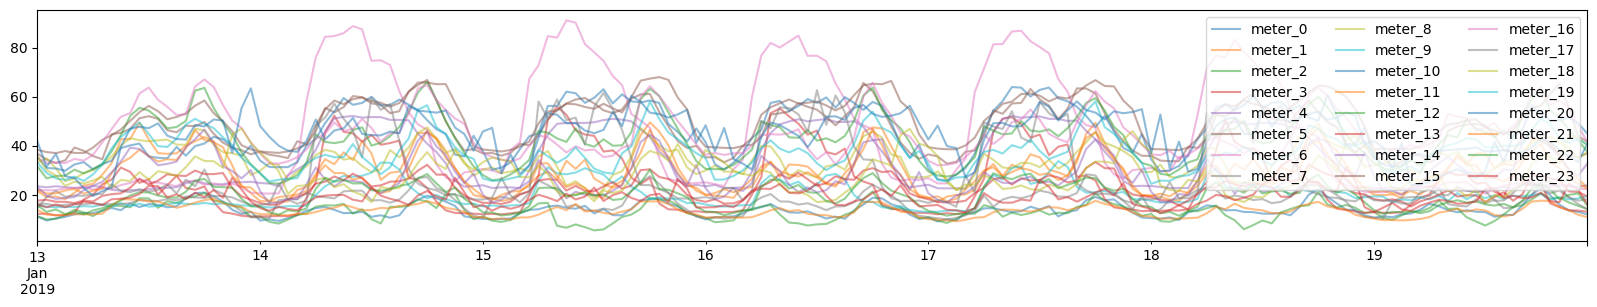

In [8]:
df_all.filter(like='meter').plot(figsize=(20, 3), alpha=0.5).legend(ncols=3, loc='upper right')
df_all.filter(like='meter').tail(24*7).plot(figsize=(20, 3), alpha=0.5).legend(ncols=3, loc='upper right')

## Scatter plots

We start to do a simple analysis scattering all the signals against each other using the `seaborn` library `pairplot` function. We are also interested in see if the current value of the power is correlated with itself at the previous day. To see this we can use the `panda`'s `shift` method. Note how the first values becom NaNs, since we cannot retrieve past values for the first 24 observations:

In [9]:
# we shift the signal by 24 steps
data['power'].shift(24)

2018-01-13 00:00:00+00:00           NaN
2018-01-13 01:00:00+00:00           NaN
2018-01-13 02:00:00+00:00           NaN
2018-01-13 03:00:00+00:00           NaN
2018-01-13 04:00:00+00:00           NaN
                                ...    
2019-01-19 19:00:00+00:00    854.405944
2019-01-19 20:00:00+00:00    782.932556
2019-01-19 21:00:00+00:00    741.659778
2019-01-19 22:00:00+00:00    685.919500
2019-01-19 23:00:00+00:00    645.111000
Freq: h, Name: power, Length: 8928, dtype: float64

We can use the `.assign` method that temporarly adds a column to the dataframe and scatter all the 4 variables

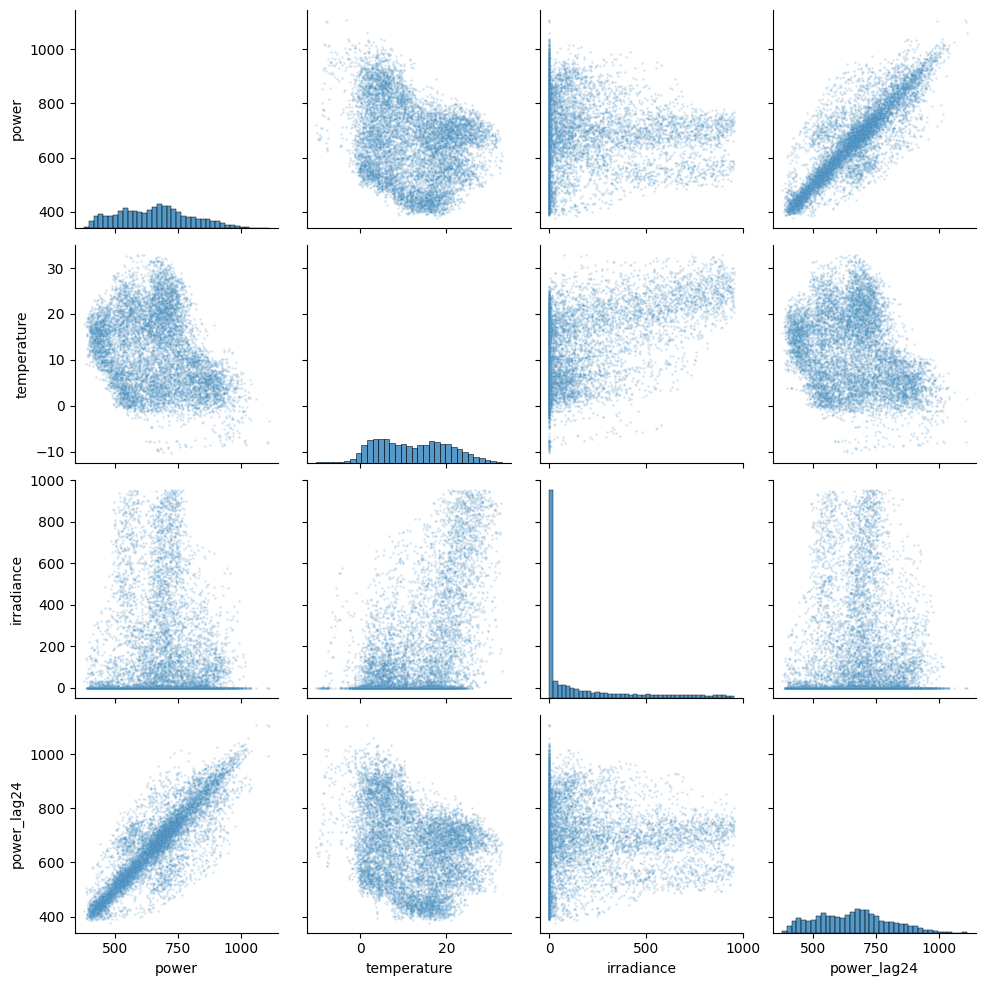

In [10]:
import seaborn as sb

sb.pairplot(data.assign(power_lag24=data['power'].shift(24)),
            plot_kws={"s": 3, "alpha":0.2})


### Mini investigation: first visual clues

Before going further, write down two hypotheses from the pairplot:

1. Which covariate seems most related to power: temperature or irradiance?
2. Does yesterday's power seem informative about today's power?
3. Which relation looks non-linear or affected by many overlapping points?


## Dense scatter plots

The pairplot is convenient, but with thousands of observations many points overlap. Hexbin and 2D density plots reveal where the data mass is concentrated.

Mini investigation:

1. Compare `power` vs `irradiance` with a normal scatter in the pairplot and with hexbin below.
2. Which plot makes the most common operating regimes easier to see?
3. Which relation is clearer: `power` vs `temperature` or `power` vs `irradiance`?


In [11]:
def relationship_density(x_var, y_var, method):
    if x_var == y_var:
        print('Choose two different variables.')
        return

    frame = data[[x_var, y_var]].dropna()
    fig, ax = plt.subplots(figsize=(7, 5))

    if method == 'hexbin':
        hb = ax.hexbin(frame[x_var], frame[y_var], gridsize=45, mincnt=1, cmap='viridis')
        fig.colorbar(hb, ax=ax, label='number of observations')
    else:
        sb.kdeplot(data=frame, x=x_var, y=y_var, fill=True, levels=20,
                   thresh=0.02, cmap='viridis', ax=ax)
        sample = frame.sample(min(len(frame), 1000), random_state=0)
        ax.scatter(sample[x_var], sample[y_var], s=4, alpha=0.15, color='black')

    ax.set_title(f'{y_var} vs {x_var} ({method})')
    ax.grid(alpha=0.2)
    plt.show()

relationship_widget = widgets.interactive(
    relationship_density,
    x_var=widgets.Dropdown(options=main_signals, value='irradiance', description='x'),
    y_var=widgets.Dropdown(options=main_signals, value='power', description='y'),
    method=widgets.ToggleButtons(options=['hexbin', 'kde'], value='hexbin', description='method'),
)
display(relationship_widget)


interactive(children=(Dropdown(description='x', index=2, options=('power', 'temperature', 'irradiance'), value…

## Interactive lag scatter

The pairplot showed one fixed lag, but time series often become interesting when we vary the lag.

Use the slider below as a small detective tool:

1. Start with lags `1`, `24`, `48`, and `24*7`.
2. Find a lag where the point cloud becomes tight again.
3. Compare `power`, `temperature`, and `irradiance`: do they share the same strongest lags?


In [12]:
def lag_scatter_explorer(signal, lag, color_by):
    series = df_all[signal].dropna()
    frame = pd.DataFrame({
        'current': series,
        'lagged': series.shift(lag),
    }).dropna()

    if frame.empty:
        print('No data available for this lag.')
        return

    plot_frame = frame.sample(min(len(frame), 5000), random_state=0).sort_index()
    corr = frame['current'].corr(frame['lagged'])

    fig, ax = plt.subplots(figsize=(7, 6))
    if color_by == 'hour':
        colors = plot_frame.index.hour
        scatter = ax.scatter(plot_frame['current'], plot_frame['lagged'], c=colors,
                             cmap='twilight', s=8, alpha=0.45)
        fig.colorbar(scatter, ax=ax, label='hour of day')
    elif color_by == 'month':
        colors = plot_frame.index.month
        scatter = ax.scatter(plot_frame['current'], plot_frame['lagged'], c=colors,
                             cmap='viridis', s=8, alpha=0.45)
        fig.colorbar(scatter, ax=ax, label='month')
    else:
        ax.scatter(plot_frame['current'], plot_frame['lagged'], s=8, alpha=0.35)

    ax.set_xlabel(f'{signal}(t)')
    ax.set_ylabel(f'{signal}(t - {lag})')
    ax.set_title(f'{signal}: lag {lag} hours, correlation = {corr:.3f}')
    ax.grid(alpha=0.2)
    plt.show()

lag_scatter_widget = widgets.interactive(
    lag_scatter_explorer,
    signal=widgets.Dropdown(options=all_signals, value='power', description='signal'),
    lag=widgets.IntSlider(value=24, min=1, max=24*14, step=1,
                          description='lag [h]', continuous_update=False),
    color_by=widgets.ToggleButtons(options=['hour', 'month', 'none'], value='hour', description='color'),
)
display(lag_scatter_widget)


interactive(children=(Dropdown(description='signal', options=('power', 'temperature', 'irradiance', 'meter_0',…

## Auto covariance function
This information can be summarized by plotting just the **linear dependence** of the signal with its previous lags, the autocorrelation function.

$$\begin{align}\rho_k = \frac{cov(x_t, x_{t-k})}{\sigma(x_t)\sigma(x_{t-k})}
\stackrel{stationary}{=}& \frac{cov(x_t, x_{t-k})}{\sigma^2(x)}\\
\stackrel{sampling}{=}& \frac{\sum_{t=1}^{t=T-k} (x_t-\hat{\mu}_x) (x_{t -k}-\hat{\mu}_x)}{T \hat{\sigma}_x^2}
\end{align}$$
where
$$
\begin{align}
\hat{\mu}_x &= \frac{1}{T} \sum_{t=1}^T x_t \qquad \qquad \ \ \  \color{green}{\text{df.mean()}} \\
\hat{\sigma}_x &= \frac{1}{T} \sum_{t=1}^T (x_t-\hat{\mu}_x)^2 \qquad \color{green}{\text{df.std()}}\\
\end{align}
$$

### Checkpoint: implement and interpret the ACF

Complete the function below using `.shift(k)`, then use the plot to answer:

1. Is `acf(data['power'], 0)` close to `1`?
2. Which lags among `1`, `24`, `48`, and `24*7` are strongest?
3. Does this confirm what you saw in the lag scatter explorer?


In [13]:
def acf(x, k):
    # TODO: replace the next line with your implementation using x.shift(k).
    return np.nan


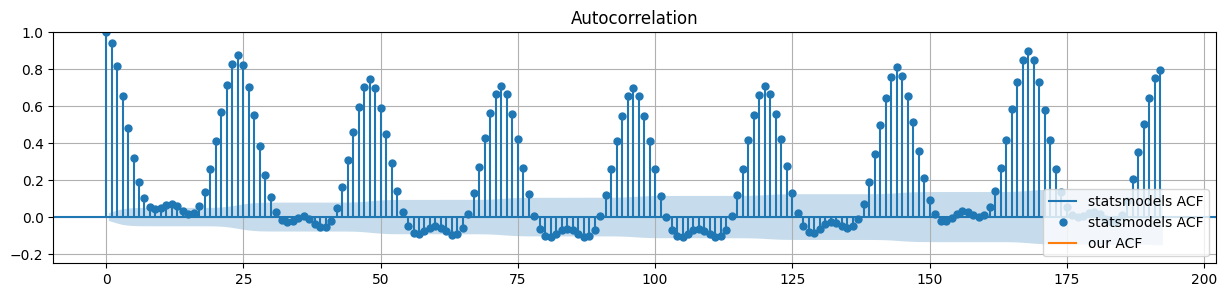

lag 0     NaN
lag 1     NaN
lag 24    NaN
lag 48    NaN
lag 168   NaN
Name: our ACF, dtype: float64

In [14]:
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(figsize=(15, 3))
plot_acf(data['power'], lags=24*8, ax=ax, label='statsmodels ACF')
plt.plot([acf(data['power'], k) for k in range(24*8)], label='our ACF')
plt.grid()
plt.ylim(-0.25, 1)
plt.legend(loc='lower right')
plt.show()

key_lags = [0, 1, 24, 48, 24*7]
pd.Series({f'lag {k}': acf(data['power'], k) for k in key_lags}, name='our ACF')


Strong seasonalities can be spotted at 24 hours intervals, with a second local maximum after 7 days (the second dashed vertical line), indicating a strong weekly seasonality.


## Embeddings
We can now try to use the two local maxima (24 and 24*7 steps) as embedding for the time series, and try to see if the signal show eveident patterns.
Loosly speaking the following chain holds:

                        patterns -->  compressibility --> forecastability

The idea: if we reshape the signal with the maxima of the ACF we can plot it as a matrix, making patterns evident.

Text(0.5, 1.0, 'Daily power consumption')

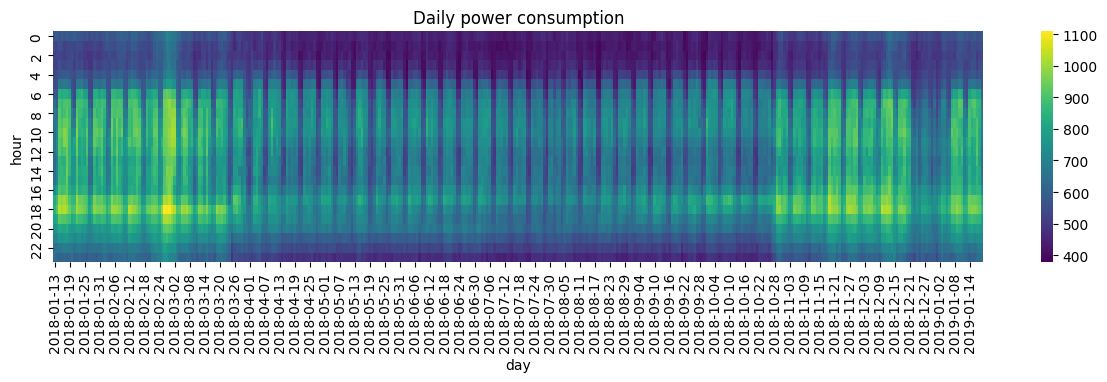

In [15]:
daily_power = data.assign(                            # assign method temporaly adds new features to a dataframe
    day=data.index.date,
    hour=data.index.hour
).pivot(index='hour', columns='day', values='power')  # pivot create a matrix from "index" and "columns"

# plot heatmap
fig, ax = plt.subplots(figsize=(15, 3))
sb.heatmap(daily_power, cmap='viridis', ax=ax)
ax.set_title('Daily power consumption')


Text(0.5, 1.0, 'Daily power consumption')

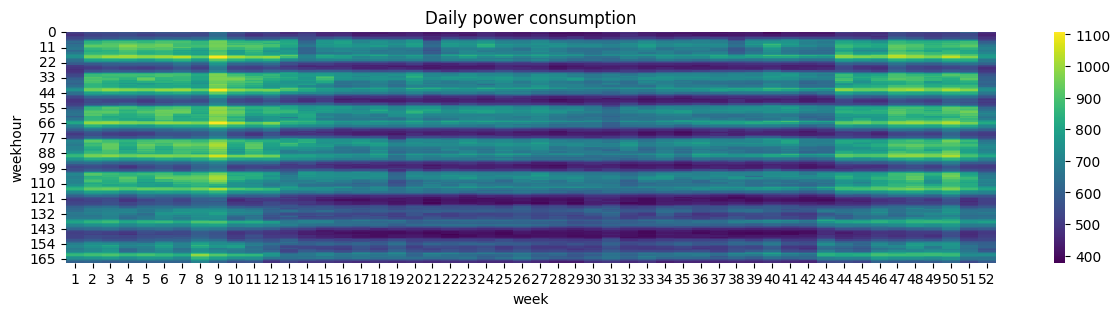

In [16]:
# the dataset spans more than one year, "week" index is not unique ->
# -> we use pivot_table which average observations falling in the same index-column bin
weekly_power = data.assign(
    week=data.index.isocalendar().week,
    weekhour= data.index.hour + data.index.dayofweek * 24
).pivot_table(index='weekhour', columns='week', values='power')

# plot heatmap
fig, ax = plt.subplots(figsize=(15, 3))
sb.heatmap(weekly_power, cmap='viridis', ax=ax)
ax.set_title('Daily power consumption')


## Interactive calendar heatmaps

The previous two heatmaps used fixed embeddings. This widget lets you change the signal and the calendar representation.

Mini investigation:

1. Use `hour x day` to compare daily fingerprints.
2. Use `weekhour x week` to inspect weekly structure.
3. Use `hour x weekday` to summarize the typical week.
4. Toggle robust scaling. When does it help?


In [17]:
def calendar_matrix(signal, embedding):
    if embedding == 'hour x day':
        return df_all.assign(
            day=df_all.index.date,
            hour=df_all.index.hour,
        ).pivot(index='hour', columns='day', values=signal)

    if embedding == 'weekhour x week':
        return df_all.assign(
            week=df_all.index.isocalendar().week.astype(int),
            weekhour=df_all.index.hour + df_all.index.dayofweek * 24,
        ).pivot_table(index='weekhour', columns='week', values=signal)

    matrix = df_all.assign(
        hour=df_all.index.hour,
        weekday=pd.Categorical(df_all.index.day_name().str[:3],
                               categories=weekday_order, ordered=True),
    ).pivot_table(index='hour', columns='weekday', values=signal, observed=False)
    return matrix.loc[:, weekday_order]

def heatmap_explorer(signal, embedding, cmap, robust_scale):
    matrix = calendar_matrix(signal, embedding)
    fig_height = 3 if embedding != 'weekhour x week' else 6
    fig, ax = plt.subplots(figsize=(15, fig_height))
    sb.heatmap(matrix, cmap=cmap, robust=robust_scale, ax=ax)
    ax.set_title(f'{signal}: {embedding}')
    plt.show()

heatmap_widget = widgets.interactive(
    heatmap_explorer,
    signal=widgets.Dropdown(options=all_signals, value='power', description='signal'),
    embedding=widgets.ToggleButtons(options=['hour x day', 'weekhour x week', 'hour x weekday'],
                                    value='hour x day', description='view'),
    cmap=widgets.Dropdown(options=['viridis', 'magma', 'coolwarm', 'cividis'], value='viridis', description='cmap'),
    robust_scale=widgets.Checkbox(value=True, description='robust scale'),
)
display(heatmap_widget)


interactive(children=(Dropdown(description='signal', options=('power', 'temperature', 'irradiance', 'meter_0',…

### Your turn: heatmap comparison

Before coding, make a prediction:

1. Which variable should have the clearest daily cycle?
2. Which variable should change most across the seasons?
3. Do you expect weekday/weekend structure in temperature or irradiance?

Then obtain the same heatmaps for `temperature` and `irradiance`. What changes compared with `power`?


In [18]:
# Create daily heatmaps for temperature and irradiance.
# Hint:
# 1. Use .assign(day=data.index.date, hour=data.index.hour)
# 2. Use .pivot(index='hour', columns='day', values='...')
# 3. Plot both matrices with sb.heatmap(...)



<Axes: xlabel='hour'>

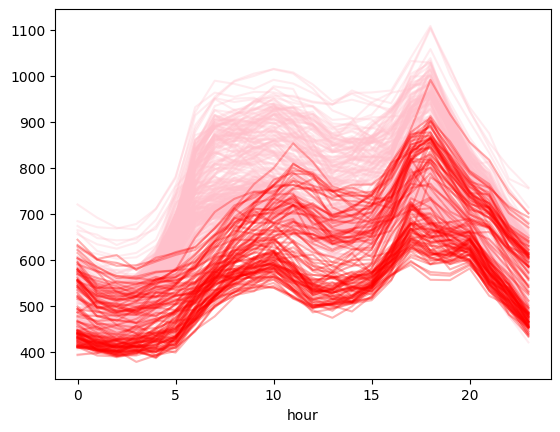

In [19]:
# get the day of the week of each column
dow = data.assign(day=data.index.date,
      hour=data.index.hour,
      dayofweek=data.index.dayofweek).pivot(index='hour',
                                            columns='day',
                                            values='dayofweek').mean()

daily_power.loc[:,dow<5].plot(color='pink', alpha=0.3, legend=False)
daily_power.loc[:,dow>=5].plot(color='r', alpha=0.3, legend=False, ax=plt.gca())

### Visualization choice checkpoint

You want to answer: **does power consumption differ between weekdays and weekends?**

Choose a plot type before coding: line plot, boxplot, scatterplot, heatmap, or histogram.

Then implement your choice below and write one sentence explaining why that plot answers the question.


In [20]:
# Hint: create a weekday/weekend column with data.index.dayofweek >= 5,
# then compare the distribution or the typical daily profile of power.



## Some exploratory analysis: meter detective work

We now move from the aggregate `power` signal to the 24 individual meters. The goal is not just to plot more lines, but to discover which meters behave similarly and which meters may be driven by different mechanisms.

Tasks:

1. Use the correlation heatmap to find the most similar and most dissimilar meter pairs.
2. Plot those pairs as time series. Do they differ by level, shape, or timing?
3. Scatter the meters against irradiance. Which meters look weather-driven?
4. Classify at least two meters as **weather-driven**, **schedule-driven**, or **hard to interpret**.


In [21]:
# Your first attempt: compute meter correlations and find the most/least similar pairs.
# Then compare your result with the helper cell below.



,pair,correlation
most dissimilar,"(meter_4, meter_18)",-0.510315
most similar,"(meter_1, meter_11)",0.935633


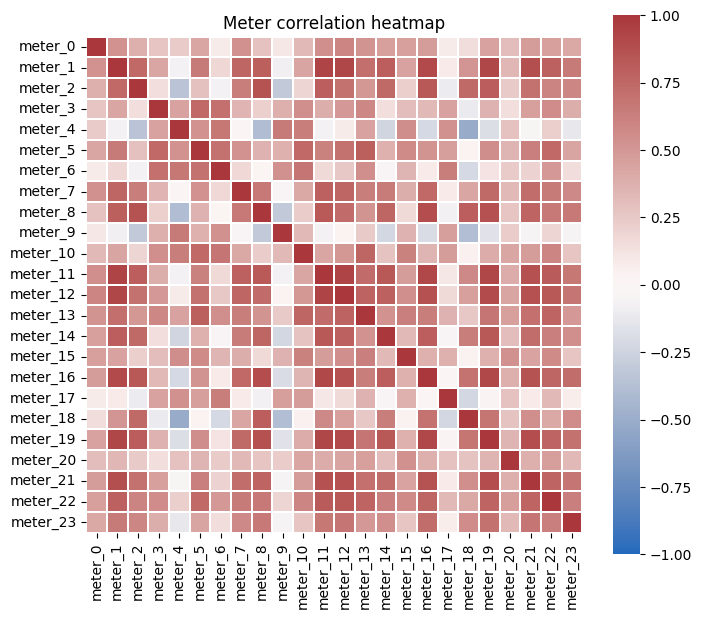

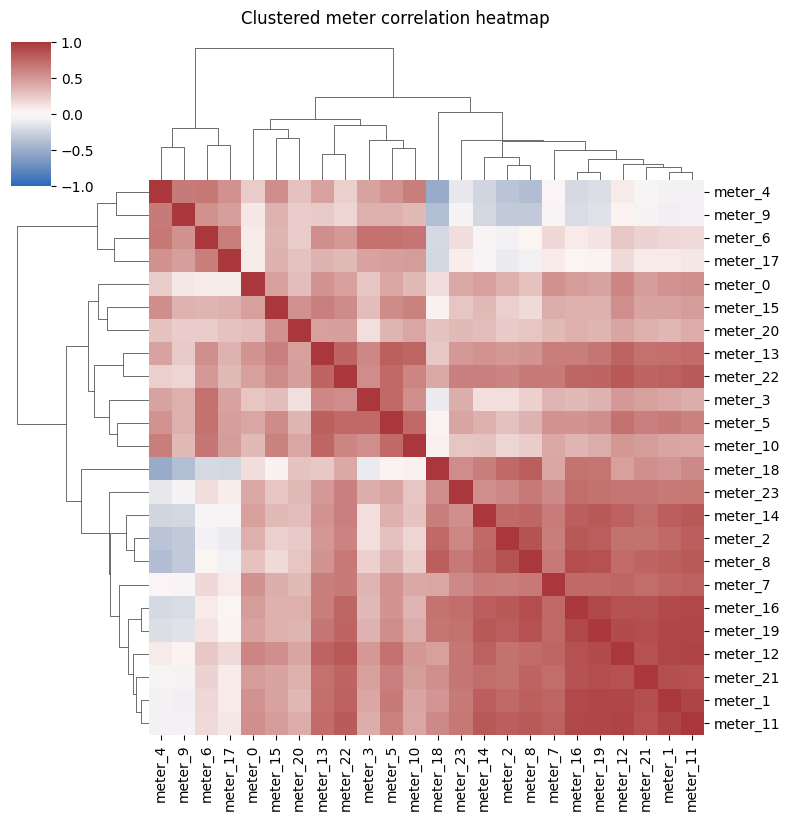

In [22]:
bottom_series = df_all.filter(like='meter')
meter_corr = bottom_series.corr()

upper_triangle = np.triu(np.ones(meter_corr.shape), k=1).astype(bool)
pair_correlations = meter_corr.where(upper_triangle).stack().sort_values()
most_dissimilar_pair = pair_correlations.index[0]
most_similar_pair = pair_correlations.index[-1]

summary = pd.DataFrame({
    'pair': [most_dissimilar_pair, most_similar_pair],
    'correlation': [pair_correlations.iloc[0], pair_correlations.iloc[-1]],
}, index=['most dissimilar', 'most similar'])
display(summary)

fig, ax = plt.subplots(figsize=(8, 7))
sb.heatmap(meter_corr, cmap='vlag', center=0, vmin=-1, vmax=1,
           square=True, linewidths=0.2, ax=ax)
ax.set_title('Meter correlation heatmap')
plt.show()

cluster_grid = sb.clustermap(meter_corr, cmap='vlag', center=0,
                             vmin=-1, vmax=1, figsize=(8, 8))
cluster_grid.fig.suptitle('Clustered meter correlation heatmap', y=1.02)
plt.show()


## Interactive meter-pair explorer

Use the defaults to start from the least correlated pair, then choose your own meters.

Mini investigation:

1. For the most dissimilar pair, check whether the difference is visible in the time plot.
2. Color the meter-vs-meter scatter by hour, month, and irradiance. Which coloring explains the separation best?
3. In the irradiance scatter, look for meters that decrease when irradiance increases. What physical explanation could create that pattern?


In [23]:
def meter_pair_explorer(meter_a, meter_b, day_range, color_by):
    if meter_a == meter_b:
        print('Choose two different meters.')
        return

    start = first_day + pd.Timedelta(days=day_range[0])
    end = first_day + pd.Timedelta(days=day_range[1] + 1)
    frame = pd.concat([bottom_series[[meter_a, meter_b]], data['irradiance']], axis=1).loc[start:end].dropna()

    if frame.empty:
        print('No data in this time window.')
        return

    if color_by == 'hour':
        colors = frame.index.hour
        cmap = 'twilight'
        color_label = 'hour of day'
    elif color_by == 'month':
        colors = frame.index.month
        cmap = 'viridis'
        color_label = 'month'
    else:
        colors = frame['irradiance']
        cmap = 'magma'
        color_label = 'irradiance'

    pair_corr = frame[meter_a].corr(frame[meter_b])
    ghi_corr_a = frame[meter_a].corr(frame['irradiance'])
    ghi_corr_b = frame[meter_b].corr(frame['irradiance'])

    fig, axs = plt.subplots(1, 3, figsize=(18, 4))

    frame[[meter_a, meter_b]].plot(ax=axs[0], linewidth=1)
    axs[0].set_title(f'time plot: {start.date()} to {(end - pd.Timedelta(days=1)).date()}')
    axs[0].set_xlabel('time')
    axs[0].grid(alpha=0.2)

    scatter = axs[1].scatter(frame[meter_a], frame[meter_b], c=colors,
                             cmap=cmap, s=8, alpha=0.45)
    axs[1].set_xlabel(meter_a)
    axs[1].set_ylabel(meter_b)
    axs[1].set_title(f'meter vs meter, corr = {pair_corr:.2f}')
    axs[1].grid(alpha=0.2)
    fig.colorbar(scatter, ax=axs[1], label=color_label)

    axs[2].scatter(frame['irradiance'], frame[meter_a], s=8, alpha=0.35, label=f'{meter_a}: r={ghi_corr_a:.2f}')
    axs[2].scatter(frame['irradiance'], frame[meter_b], s=8, alpha=0.35, label=f'{meter_b}: r={ghi_corr_b:.2f}')
    axs[2].set_xlabel('irradiance')
    axs[2].set_ylabel('meter reading')
    axs[2].set_title('relationship with irradiance')
    axs[2].grid(alpha=0.2)
    axs[2].legend()

    plt.tight_layout()
    plt.show()

meter_pair_widget = widgets.interactive(
    meter_pair_explorer,
    meter_a=widgets.Dropdown(options=meter_cols, value=most_dissimilar_pair[0], description='meter A'),
    meter_b=widgets.Dropdown(options=meter_cols, value=most_dissimilar_pair[1], description='meter B'),
    day_range=widgets.IntRangeSlider(value=[0, min(30, n_days)], min=0, max=n_days, step=1,
                                     description='days', continuous_update=False,
                                     layout=widgets.Layout(width='95%')),
    color_by=widgets.ToggleButtons(options=['hour', 'month', 'irradiance'], value='hour', description='color'),
)
display(meter_pair_widget)


interactive(children=(Dropdown(description='meter A', index=4, options=('meter_0', 'meter_1', 'meter_2', 'mete…

# BONUS: forecasting by whithening
In the following we will explore a powerful method to produce probabilistic forecasts of a time series.  

Idea: **if we can make the TS ~white noise through transformations, we can predict it by sampling from the noise and inverting the transform**

Matematically, if
$$f_1(f_2(..f_n(x))) \quad \sim \text{i.i.d.} \quad \mathcal{N}(0, \sigma)$$
then
$$\hat{x}_{t:t+h} = f_n^{-1}(f_{n-1}^{-1}(..f_1^{-1}(\mathcal{N}(0, \sigma))))$$



In [24]:
# let's start by splitting the time series in a training and a test set
p_tr = data['power'].iloc[:-24]
p_te = data['power'].iloc[-24:]


we will apply just two transformations: difference from previous week values and difference from previous step

<Axes: >

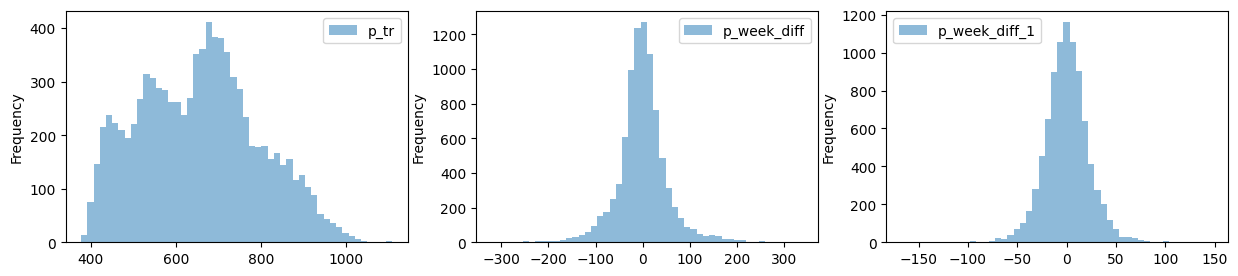

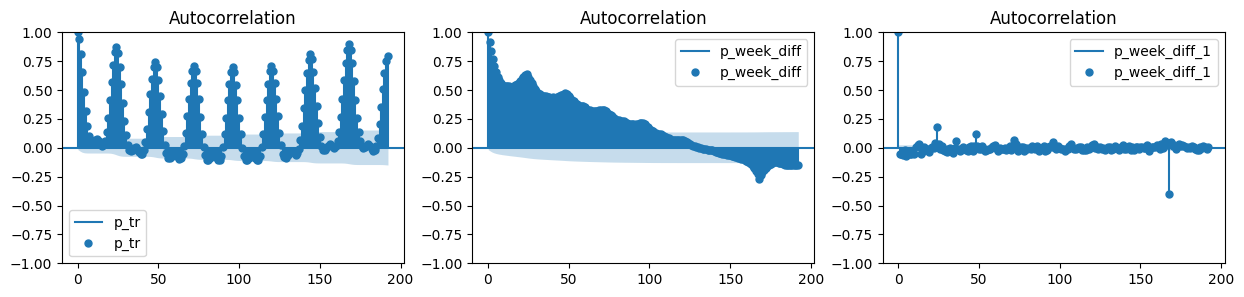

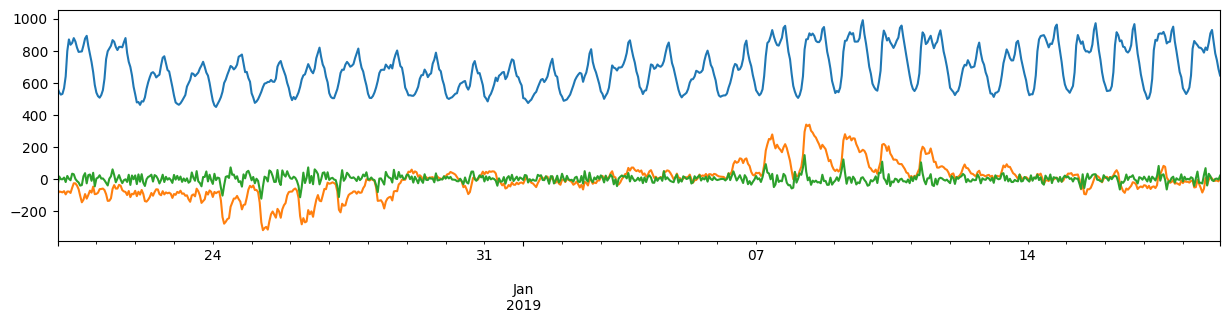

In [25]:
p_week_diff = p_tr.diff(24*7)
p_week_diff_1 = p_week_diff.diff(1)

# plot histograms of p_tr and the other two transfomations
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1, 3, figsize=(15, 3))
p_tr.plot.hist(ax=axs[0], bins=50, alpha=0.5, label='p_tr')
p_week_diff.plot.hist(ax=axs[1], bins=50, alpha=0.5, label='p_week_diff')
p_week_diff_1.plot.hist(ax=axs[2], bins=50, alpha=0.5, label='p_week_diff_1')
for ax in axs:
    ax.legend()


# plot ACF functions for all the three signals
fig, axs = plt.subplots(1, 3, figsize=(15, 3))
plot_acf(p_tr, lags=24*8, ax=axs[0], label='p_tr')
plot_acf(p_week_diff.dropna(), lags=24*8, ax=axs[1], label='p_week_diff')
plot_acf(p_week_diff_1.dropna(), lags=24*8, ax=axs[2], label='p_week_diff_1')
for ax in axs:
    ax.legend()

plt.figure(figsize=(15, 3))
(p_tr).tail(24*30).plot()
p_week_diff.tail(24*30).plot()
p_week_diff_1.tail(24*30).plot()



<Axes: >

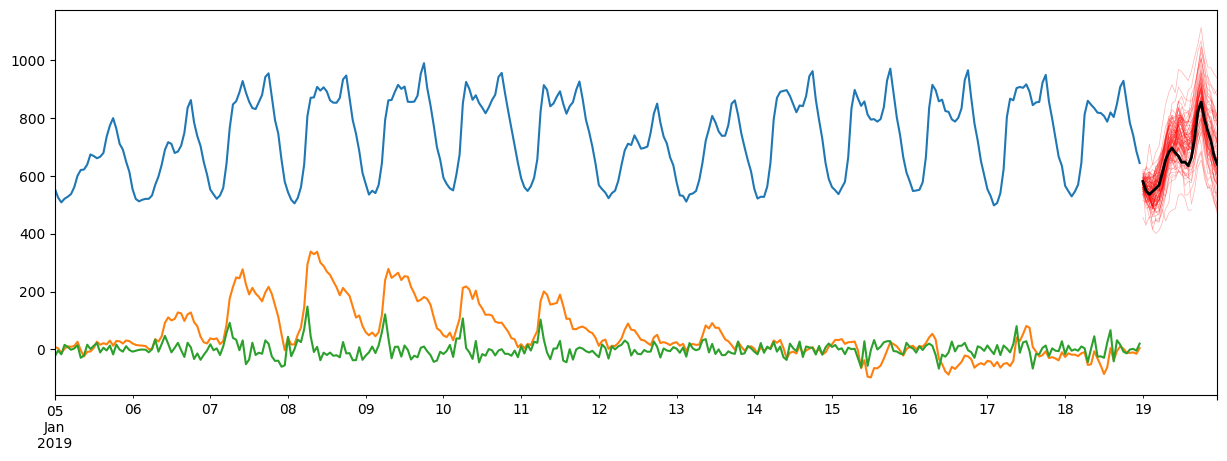

In [26]:
import numpy as np

for i in range(100):
  p_hat =  p_tr.iloc[-24*7:-24*6] + np.random.choice(p_week_diff_1, 24).cumsum()  # values of previous week + integrated samples of p_week_diff_1
  p_hat.index = p_te.index
  p_hat.plot(color='r', alpha=0.3, linewidth=0.5)


# plot the forecast and some hisory
(p_tr).tail(24*14).plot(figsize=(15, 5))
p_week_diff.tail(24*14).plot()
p_week_diff_1.tail(24*14).plot()
p_te.plot(color='k', linewidth=2)
